<table>
    <tr> 
    <th>                                                                                   
        <table>
            <tr>                                                                                   
                 <th  style="font-size:150%;ftext-align:left;background-color:#053061;color:white;">Valeur</th>
                 <th  style="font-size:150%;text-align:left;background-color:#053061;color:white;">Nom classe</th>
             </tr>
            <tr>
                <th  style="font-size:150%;text-align:left">0</th>
                <th  style="font-size:150%;text-align:left">eosinophil</th>
            </tr>
            <tr>
                <th  style="font-size:150%;text-align:left">1</th>
                <th  style="font-size:150%;text-align:left">lymphocyte</th>
            </tr>
            <tr>
                <th  style="font-size:150%;text-align:left">2</th>
                <th  style="font-size:150%;text-align:left">monocyte</th>
            </tr>
            <tr>
                <th  style="font-size:150%;text-align:left">3</th>
                <th  style="font-size:150%;text-align:left">neutrophil</th>
            </tr>
        </table>
    </th>
    <th> 
        <div style='padding:15px;color:#030aa7;font-size:240%;text-align: center;font-style: italic;font-weight: bold;font-family: Georgia, serif'>BloodMNIST<br> Standardized Biomedical Images</div>
        <div style='text-align: center'>
            <img src="https://raw.githubusercontent.com/rbizoi/DeepLearning/refs/heads/main/images/bood-4.png" width="512">
        </div>      
    </th>
    </tr>
</table>

<div style='padding:15px;color:#030aa7;font-size:100%;text-align: left;font-family: Georgia, serif'><a href="https://www.kaggle.com/datasets/kylewang1999/pbc-dataset">Veuillez vous référer à la page officielle pour plus de détails.</a></div>

>> **site du projet** : https://data.mendeley.com/datasets/snkd93bnjr/1

>> **article** : https://doi.org/10.1016/j.cmpb.2019.105020

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Initialisation du document</div></b>

In [19]:
import os
# import json
# @param ["tensorflow", "jax", "torch"]
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ['KERAS_BACKEND'] = 'tensorflow'  
os.environ['TF_XLA_FLAGS'] = '--tf_xla_enable_xla_devices'
os.environ['TF_CPP_MIN_LOG_LEVEL']='5'

import tensorflow as tf
import keras
tf.get_logger().setLevel('ERROR')

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:100%; border-radius:10px 10px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Import libriries </div></b>

In [20]:
import numpy as np, pandas as pd, seaborn as sns, warnings, os, sys, time
from matplotlib import pyplot as plt

warnings.filterwarnings(action="ignore")

if int(str(sns.__version__).split('.')[1]) > 8 : 
    plt.style.use('seaborn-v0_8-darkgrid')
else:
    plt.style.use('seaborn-darkgrid')
    
sns.set(font_scale=2)

print(f"""La version des librairies utilisées :

Tensorflow : {tf.__version__}\tCUDA {tf.test.is_built_with_cuda()}\tGPU {tf.test.is_built_with_gpu_support()}\tXLA {tf.test.is_built_with_xla()}
Keras      : {keras.version()}
Pandas     : {pd.__version__}
NumPy      : {np.__version__}""")

La version des librairies utilisées :

Tensorflow : 2.19.1	CUDA True	GPU True	XLA True
Keras      : 3.12.0
Pandas     : 2.3.2
NumPy      : 1.26.4


## <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Importer les fichiers nécessaires à l’exécution</div></b>

In [21]:
!pip install gitpython

In [22]:
import requests, os

# Dépôt et chemin
def chargementDonnees(user="rbizoi",
                      repo="FHU_TARGET_ScientificDays_2025",
                      repertoire="outils",   # sous-dossier à récupérer
                      branch = "main"):

    url = f"https://api.github.com/repos/{user}/{repo}/contents/{repertoire}?ref={branch}"
    r = requests.get(url)
    files = r.json()

    if not (os.path.exists(repertoire) & os.path.isdir(repertoire)) :
        
        os.makedirs(repertoire, exist_ok=True)
        
        for file in files:
            if file["type"] == "file":
                download_url = file["download_url"]
                file_data = requests.get(download_url).content
                with open(os.path.join(repertoire, file["name"]), "wb") as f:
                    f.write(file_data)
        print(f"Le répertoire - {repertoire} { 'a bien' if os.path.exists(repertoire) & os.path.isdir(repertoire) else 'n’a pas'} été chargé  ")
    else:                    
         print(f"Le répertoire {repertoire} existe dejà ")
    

chargementDonnees(user="rbizoi",
                      repo="FHU_TARGET_ScientificDays_2025",
                      repertoire="outils",   # sous-dossier à récupérer
                      branch = "main")

# repertoire = 'donnees/BloodMNIST'
repertoire = 'donnees/BloodMNIST224x224-4'
# repertoire = 'donnees/BloodMNIST224x224-8'
# repertoire = 'donnees/BloodMNIST36x36-4'
# repertoire = 'donnees/BloodMNIST36x36-8'
# repertoire = 'donnees/BloodObjectDetection'
# repertoire = 'donnees/BloodSegmented'

chargementDonnees( user="rbizoi",
                   repo="FHU_TARGET_ScientificDays_2025",
                   repertoire=repertoire,   # sous-dossier à récupérer
                   branch = "main")
chargementDonnees( user="rbizoi",
                   repo="FHU_TARGET_ScientificDays_2025",
                   repertoire=f'{repertoire}/apprentissage',   # sous-dossier à récupérer
                   branch = "main")
chargementDonnees( user="rbizoi",
                   repo="FHU_TARGET_ScientificDays_2025",
                   repertoire=f'{repertoire}/validation',   # sous-dossier à récupérer
                   branch = "main")

Le répertoire outils existe dejà 
Le répertoire donnees/BloodMNIST224x224-4 existe dejà 
Le répertoire donnees/BloodMNIST224x224-4/apprentissage existe dejà 
Le répertoire donnees/BloodMNIST224x224-4/validation existe dejà 


# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Outils du document</div></b>

In [23]:
sys.path.append(os.path.abspath('outils/'))

In [24]:
if 'configProjet' in sys.modules.keys():  del(sys.modules['configProjet'])
if 'configModele' in sys.modules.keys():  del(sys.modules['configModele'])

In [25]:
from configProjet import palette, initParametresProjet 
from configProjet import afficheHistoriqueEntrainement, afficheProbabilites, afficheMatriceConfusion, afficheDataset, afficheDistributionsPipe

In [26]:
from configModele import modelDictionnaire, initParametresExecution, getPipelineDataset
from configModele import creationCompilationModele, creationRappelsExecution, entrainementModele
from configModele import sauvegarderModel, sauvegardeHistorique, executeApprentissageChoixClassifieurs
from configModele import modelCNNSimple, modelPersonalise, modelPersonaliseInception

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Paramétrés de l’exécution et les flux de lecture des fichiers TFRecors</div></b>

In [27]:
image_size,batch_size,epochs,dictLabels,nombreClasses,pipelineApprentissage,pipelineValidation = \
       initParametresExecution(image_size=(160, 160, 3),
                            batch_size = 32,
                            epochs=128,
                            repertoire=repertoire,
                            cycle_length=None,
                            deterministic=None,
                            repetition=8,
                            bufferAleatoire=1024)

In [28]:
print(f"""
  repertoire    = {repertoire}
  image_size    = {image_size}
  batch_size    = {batch_size}
  epochs        = {epochs}
  nombreClasses = {nombreClasses}
  dictLabels    = {dictLabels}
       """)


  repertoire    = donnees/BloodMNIST224x224-4
  image_size    = (160, 160, 3)
  batch_size    = 32
  epochs        = 128
  nombreClasses = 4
  dictLabels    = {0: 'eosinophil', 1: 'lymphocyte', 2: 'monocyte', 3: 'neutrophil'}
       


# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Affichage données</div></b>

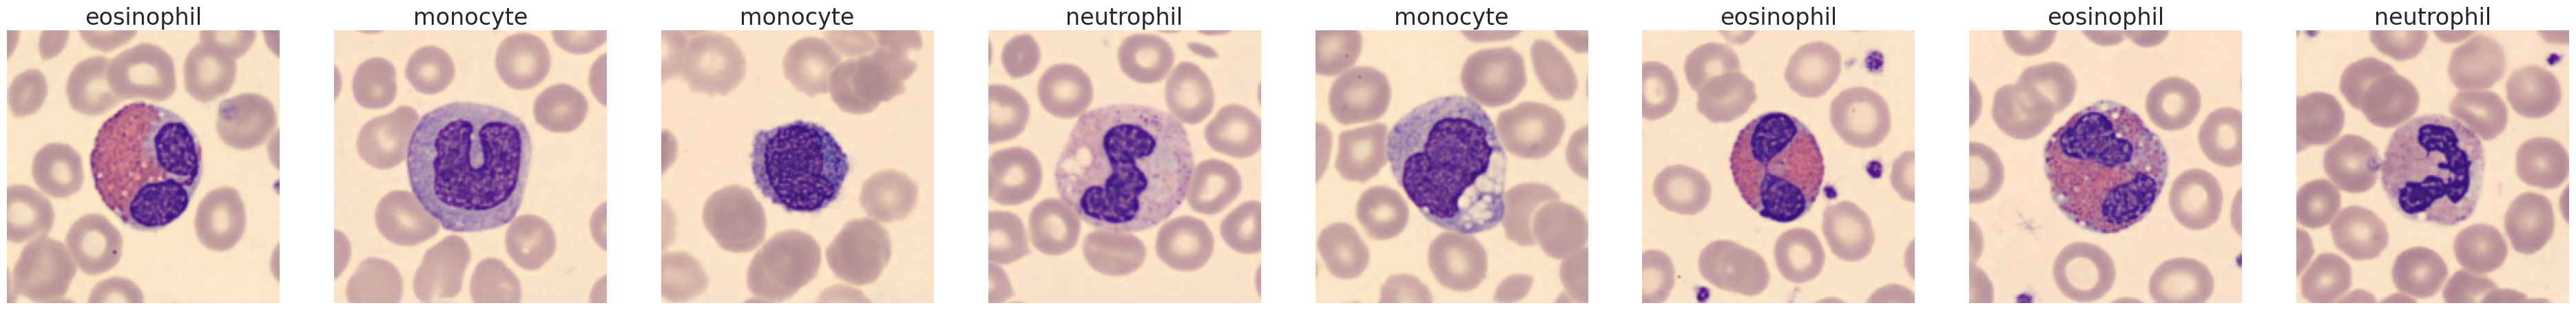

In [29]:
images, labels = next(iter(pipelineApprentissage))
nombresImages = 8
afficheDataset(images, labels,nombresImages,6*nombresImages,dictLabels,cmap=None)

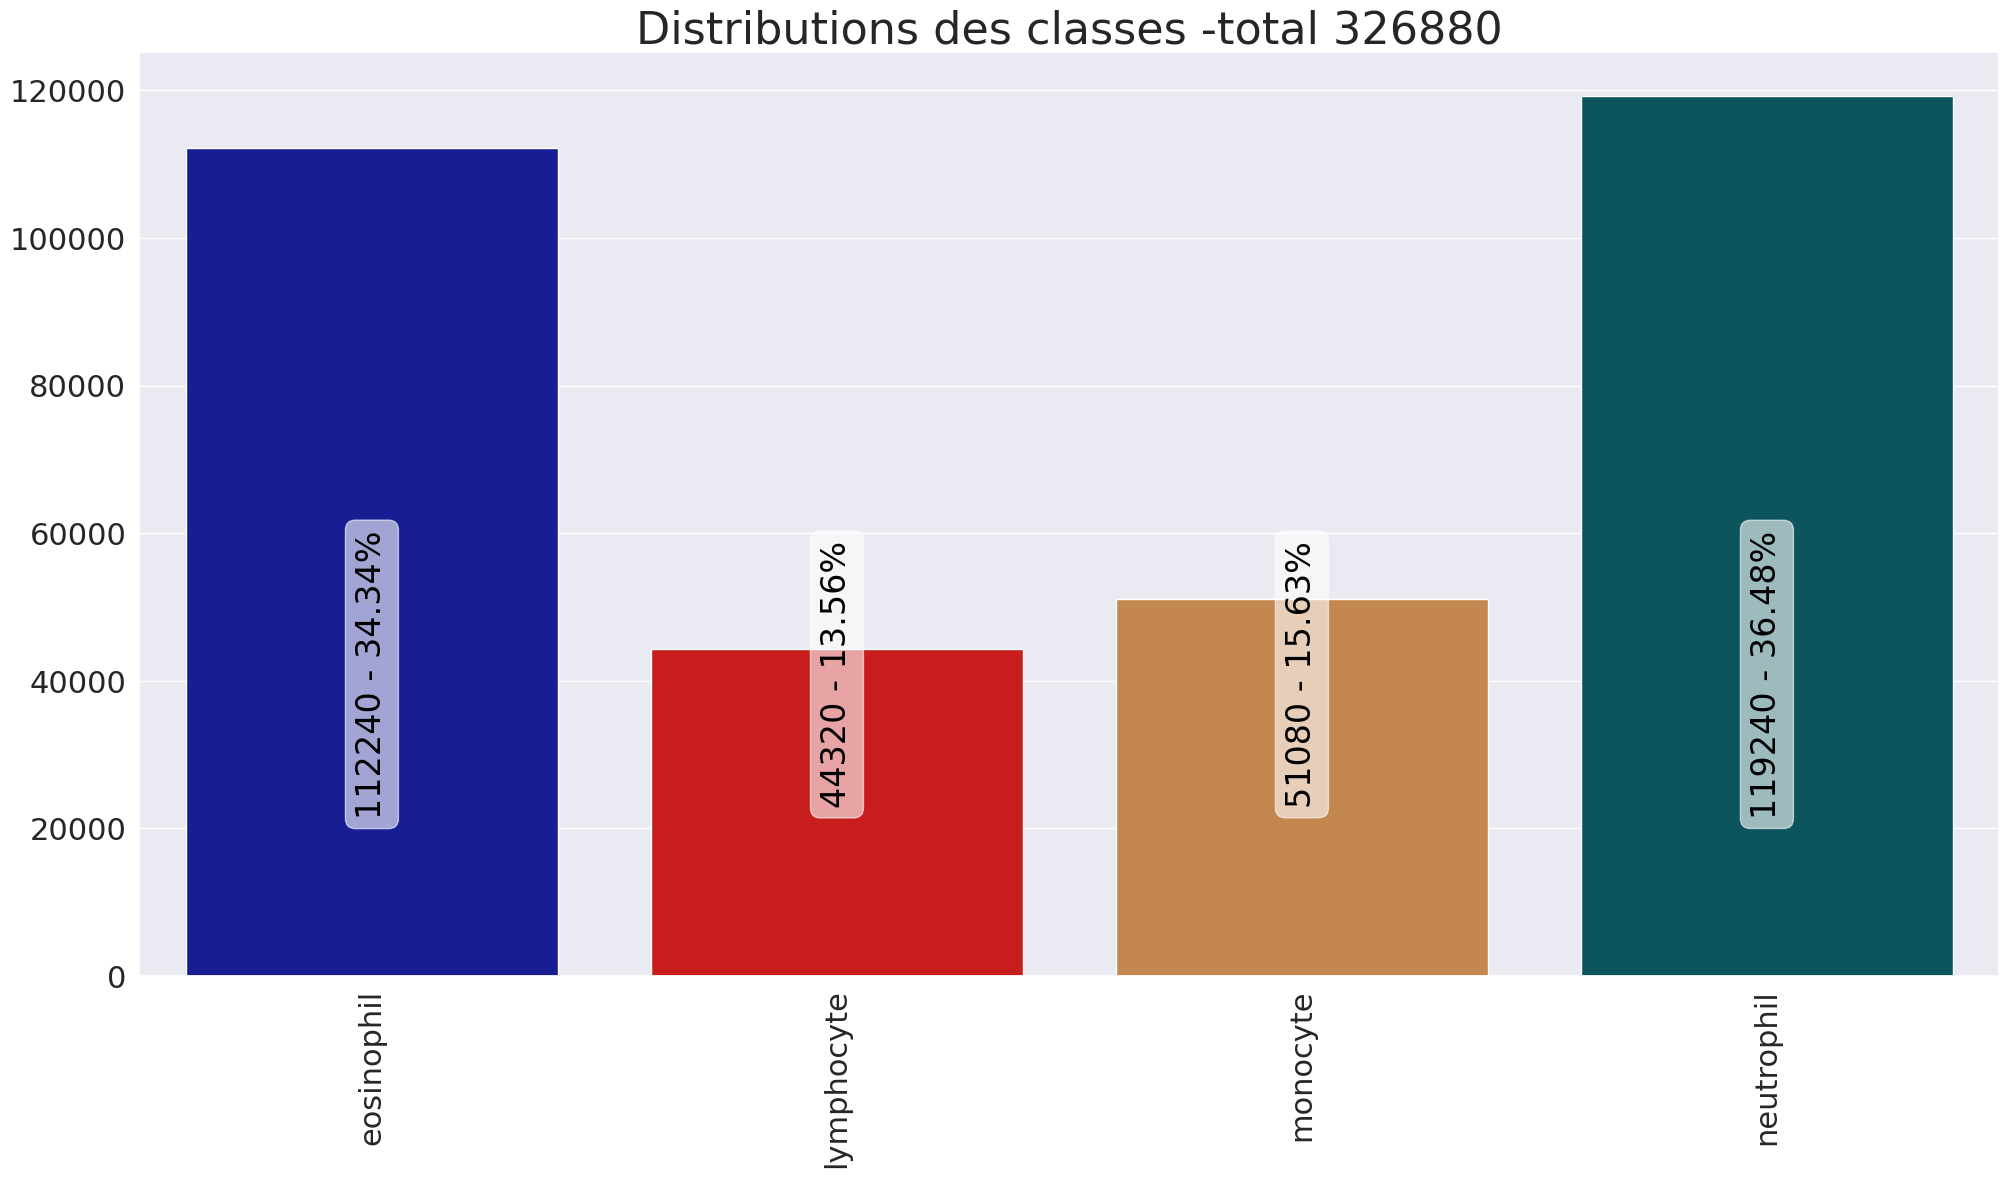

In [30]:
afficheDistributionsPipe(pipelineApprentissage, dictLabels, palette, repertoireEnregistrement=None)

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Choix du modèle</div></b>
             
<table>
    <tr>                                                                                   
         <th  style="font-size:150%;ftext-align:left;background-color:#053061;color:white;">Nom</th>
         <th  style="font-size:150%;text-align:left;background-color:#053061;color:white;">Description</th>
         <th  style="font-size:150%;text-align:left;background-color:#053061;color:white;">Référence</th>
     </tr>
    <tr>
        <th  style="font-size:130%;text-align:left">VGG19</th>
        <th  style="font-size:130%;text-align:left">Very Deep Convolutional Networks for Large-Scale Image Recognition (ICLR 2015)</th>
        <th  style="font-size:130%;text-align:left"><a href="https://arxiv.org/pdf/1409.1556">https://arxiv.org/pdf/1409.1556</a> </th>
    </tr>
    <tr>
        <th  style="font-size:130%;text-align:left">ResNet152V2</th>
        <th  style="font-size:130%;text-align:left">Identity Mappings in Deep Residual Networks (CVPR 2016)</th>
        <th  style="font-size:130%;text-align:left"><a href="https://arxiv.org/pdf/1603.05027">https://arxiv.org/pdf/1603.05027</a> </th>
    </tr>
    <tr>
        <th  style="font-size:130%;text-align:left">InceptionV3</th>
        <th  style="font-size:130%;text-align:left">Rethinking the Inception Architecture for Computer Vision (CVPR 2016)</th>
        <th  style="font-size:130%;text-align:left"><a href="https://arxiv.org/pdf/1512.00567">https://arxiv.org/pdf/1512.00567</a> </th>
    </tr>
    <tr>
        <th  style="font-size:130%;text-align:left">Xception</th>
        <th  style="font-size:130%;text-align:left">Deep Learning with Depthwise Separable Convolutions (CVPR 2017)</th>
        <th  style="font-size:130%;text-align:left"><a href="https://arxiv.org/pdf/1610.02357">https://arxiv.org/pdf/1610.02357</a> </th>
    </tr>
    <tr>
        <th  style="font-size:130%;text-align:left">InceptionResNetV2</th>
        <th  style="font-size:130%;text-align:left">Inception-v4, Inception-ResNet and the Impact of Residual Connections on Learning (AAAI 2017)</th>
        <th  style="font-size:130%;text-align:left"><a href="https://arxiv.org/pdf/1602.07261">https://arxiv.org/pdf/1602.07261</a> </th>
    </tr>    
    <tr>
        <th  style="font-size:130%;text-align:left">DenseNet201</th>
        <th  style="font-size:130%;text-align:left">Densely Connected Convolutional Networks (CVPR 2017)</th>
        <th  style="font-size:130%;text-align:left"><a href="https://arxiv.org/pdf/1608.06993">https://arxiv.org/pdf/1608.06993</a> </th>
    </tr>
    <tr>
        <th  style="font-size:130%;text-align:left">MobileNetV3Small</th>
        <th  style="font-size:130%;text-align:left">Inverted Residuals and Linear Bottlenecks (CVPR 2018)</th>
        <th  style="font-size:130%;text-align:left"><a href="https://arxiv.org/pdf/1801.04381">https://arxiv.org/pdf/1801.04381</a> </th>
    </tr>
    <tr>
        <th  style="font-size:130%;text-align:left">EfficientNet</th>
        <th  style="font-size:130%;text-align:left">Rethinking Model Scaling for Convolutional Neural Networks (ICML 2019)</th>
        <th  style="font-size:130%;text-align:left"><a href="https://arxiv.org/pdf/1905.11946">https://arxiv.org/pdf/1905.11946</a> </th>
    </tr>
    <tr>
        <th  style="font-size:130%;text-align:left">EfficientNetV2</th>
        <th  style="font-size:130%;text-align:left">Smaller Models and Faster Training (ICML 2021)</th>
        <th  style="font-size:130%;text-align:left"><a href="https://arxiv.org/pdf/2104.00298">https://arxiv.org/pdf/2104.00298</a> </th>
    </tr>    
    <tr>
        <th  style="font-size:130%;text-align:left">ConvNeXtSmall</th>
        <th  style="font-size:130%;text-align:left">A ConvNet for the 2020s (CVPR 2022)</th>
        <th  style="font-size:130%;text-align:left"><a href="https://arxiv.org/pdf/2201.03545">https://arxiv.org/pdf/2201.03545</a> </th>
    </tr>    
</table>


In [31]:
print('Vous pouvez choisir parmi les noms dans la liste suivante :')
for nom in modelDictionnaire : print(nom, end=' \t')

Vous pouvez choisir parmi les noms dans la liste suivante :
ResNet152V2 	DenseNet201 	Xception 	InceptionV3 	InceptionResNetV2 	MobileNetV3Small 	EfficientNetV2S 	ConvNeXtSmall 	

In [32]:
nomModel = 'ResNet50'

In [33]:
repertoireEnregistrement,repertoireSauvegardes,repertoireModelCKP,repertoireModelSauvegarde,repertoireModelLogs = \
            initParametresProjet(nomProjet=f"5-bloodMNIST-{nomModel}-160x160-bs{batch_size:02d}-epochs{epochs:03d}",repertoireProjet='ResultatsExecutions')

In [34]:
repertoireSauvegardes

'ResultatsExecutions/5-bloodMNIST-ResNet50-160x160-bs32-epochs128/model.sauvegardes'

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Création et compilation d'un modèle</div></b>

In [14]:
model = creationCompilationModele( nomModel, 
                                   modelDictionnaire, 
                                   image_size, 
                                   nombreClasses)

In [15]:
model.summary()

Model: "ResNet50_blood"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 160, 160)  │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 160, 160)  │          0 │ input_layer[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 160, 160)  │          0 │ input_layer[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 160, 160,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 160, 160,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 5, 5,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ couche_prob (Dense) │ (None, 4)         │      8,196 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,595,908 (90.01 MB)

 Trainable params: 23,542,788 (89.81 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [16]:
model.compile(
        optimizer=keras.optimizers.AdamW(1e-03), 
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy')],
    )

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:100%; border-radius:10px 10px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Rappels d’exécution (callbacks)</div></b>

In [17]:
callbacks = creationRappelsExecution(repertoireModelSauvegarde,
                                     repertoireModelCKP,
                                     repertoireModelLogs,
                                     patienceArretPrecoce=8,
                                     initial_lrate=1e-03,
                                     max_lrate=1e-03,
                                     min_lrate=1e-05,
                                     epochs_runup_lrate=0,
                                     epochs_sustain_lrate=0,
                                     drop_lrate=0.98)

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:100%; border-radius:10px 10px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Evolution du taux d'apprentissage</div></b>

In [18]:
def evolutionTauxApprentissage(epoch,
                               initial_lrate=1e-03,
                               max_lrate=1e-03,
                               min_lrate=1e-05,
                               epochs_runup_lrate=0,
                               epochs_sustain_lrate=0,
                               drop_lrate=0.98):
    # epochs_drop = epochs * 0.1
    if epoch < epochs_runup_lrate:
        lrate = (max_lrate - initial_lrate) / epochs_runup_lrate * epoch + initial_lrate
    elif epoch < epochs_runup_lrate + epochs_sustain_lrate:
        lrate = max_lrate
    else:
        lrate = (max_lrate - min_lrate) * drop_lrate**(epoch - epochs_runup_lrate - epochs_sustain_lrate) + min_lrate
    return lrate

L'évolution du taux d'apprentissage : du 0.001 à 8.61e-05


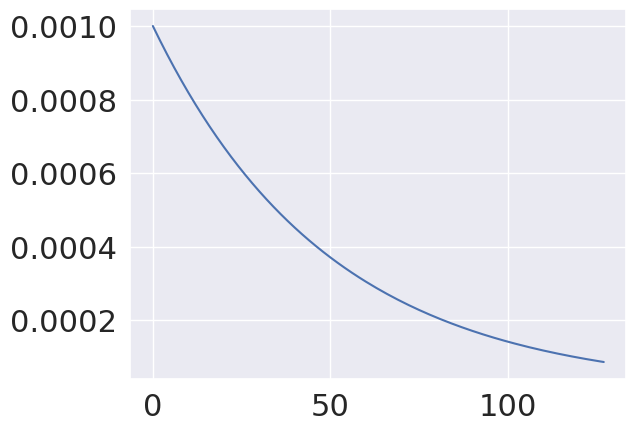

In [19]:
rng = [i for i in range(epochs)]
y = [evolutionTauxApprentissage(x) for x in rng]
plt.plot(rng, y)

print(f"L'évolution du taux d'apprentissage : du {y[0]:.3g} à {min(y):.3g}")

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Entrainement du modèle</div></b>


In [20]:
historiqueApprentissage, model = entrainementModele( model, 
                                                     pipelineApprentissage,
                                                     pipelineValidation, 
                                                     epochs, 
                                                     batch_size,
                                                     callbacks,
                                                     2, #verbose=2, 
                                                     repertoireModelSauvegarde)

Epoch 1/128


I0000 00:00:1757250836.473770   80681 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



Epoch 1: val_loss improved from inf to 0.31590, saving model to ../ResultatsExecutions/5-bloodMNIST-ResNet50-160x160-bs32-epochs128/model.sauvegardes/sauvegarde/modelVLoss.keras
1277/1277 - 67s - 52ms/step - accuracy: 0.9543 - loss: 0.1579 - val_accuracy: 0.8910 - val_loss: 0.3159 - learning_rate: 0.0010
Epoch 2/128

Epoch 2: val_loss did not improve from 0.31590
1277/1277 - 31s - 25ms/step - accuracy: 0.9825 - loss: 0.0570 - val_accuracy: 0.8040 - val_loss: 1.0186 - learning_rate: 9.8020e-04
Epoch 3/128

Epoch 3: val_loss improved from 0.31590 to 0.13908, saving model to ../ResultatsExecutions/5-bloodMNIST-ResNet50-160x160-bs32-epochs128/model.sauvegardes/sauvegarde/modelVLoss.keras
1277/1277 - 33s - 26ms/step - accuracy: 0.9870 - loss: 0.0417 - val_accuracy: 0.9570 - val_loss: 0.1391 - learning_rate: 9.6080e-04
Epoch 4/128

Epoch 4: val_loss did not improve from 0.13908
1277/1277 - 31s - 25ms/step - accuracy: 0.9889 - loss: 0.0360 - val_accuracy: 0.9372 - val_loss: 0.1816 - learning

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Affichage historique de l'apprentissage </div></b>

In [21]:
historique = sauvegardeHistorique(historiqueApprentissage,
                                  repertoireSauvegardes,
                                  nomSauvegarde=f'historique-{nomModel}-bs{batch_size:02d}-epochs{epochs:03d}')

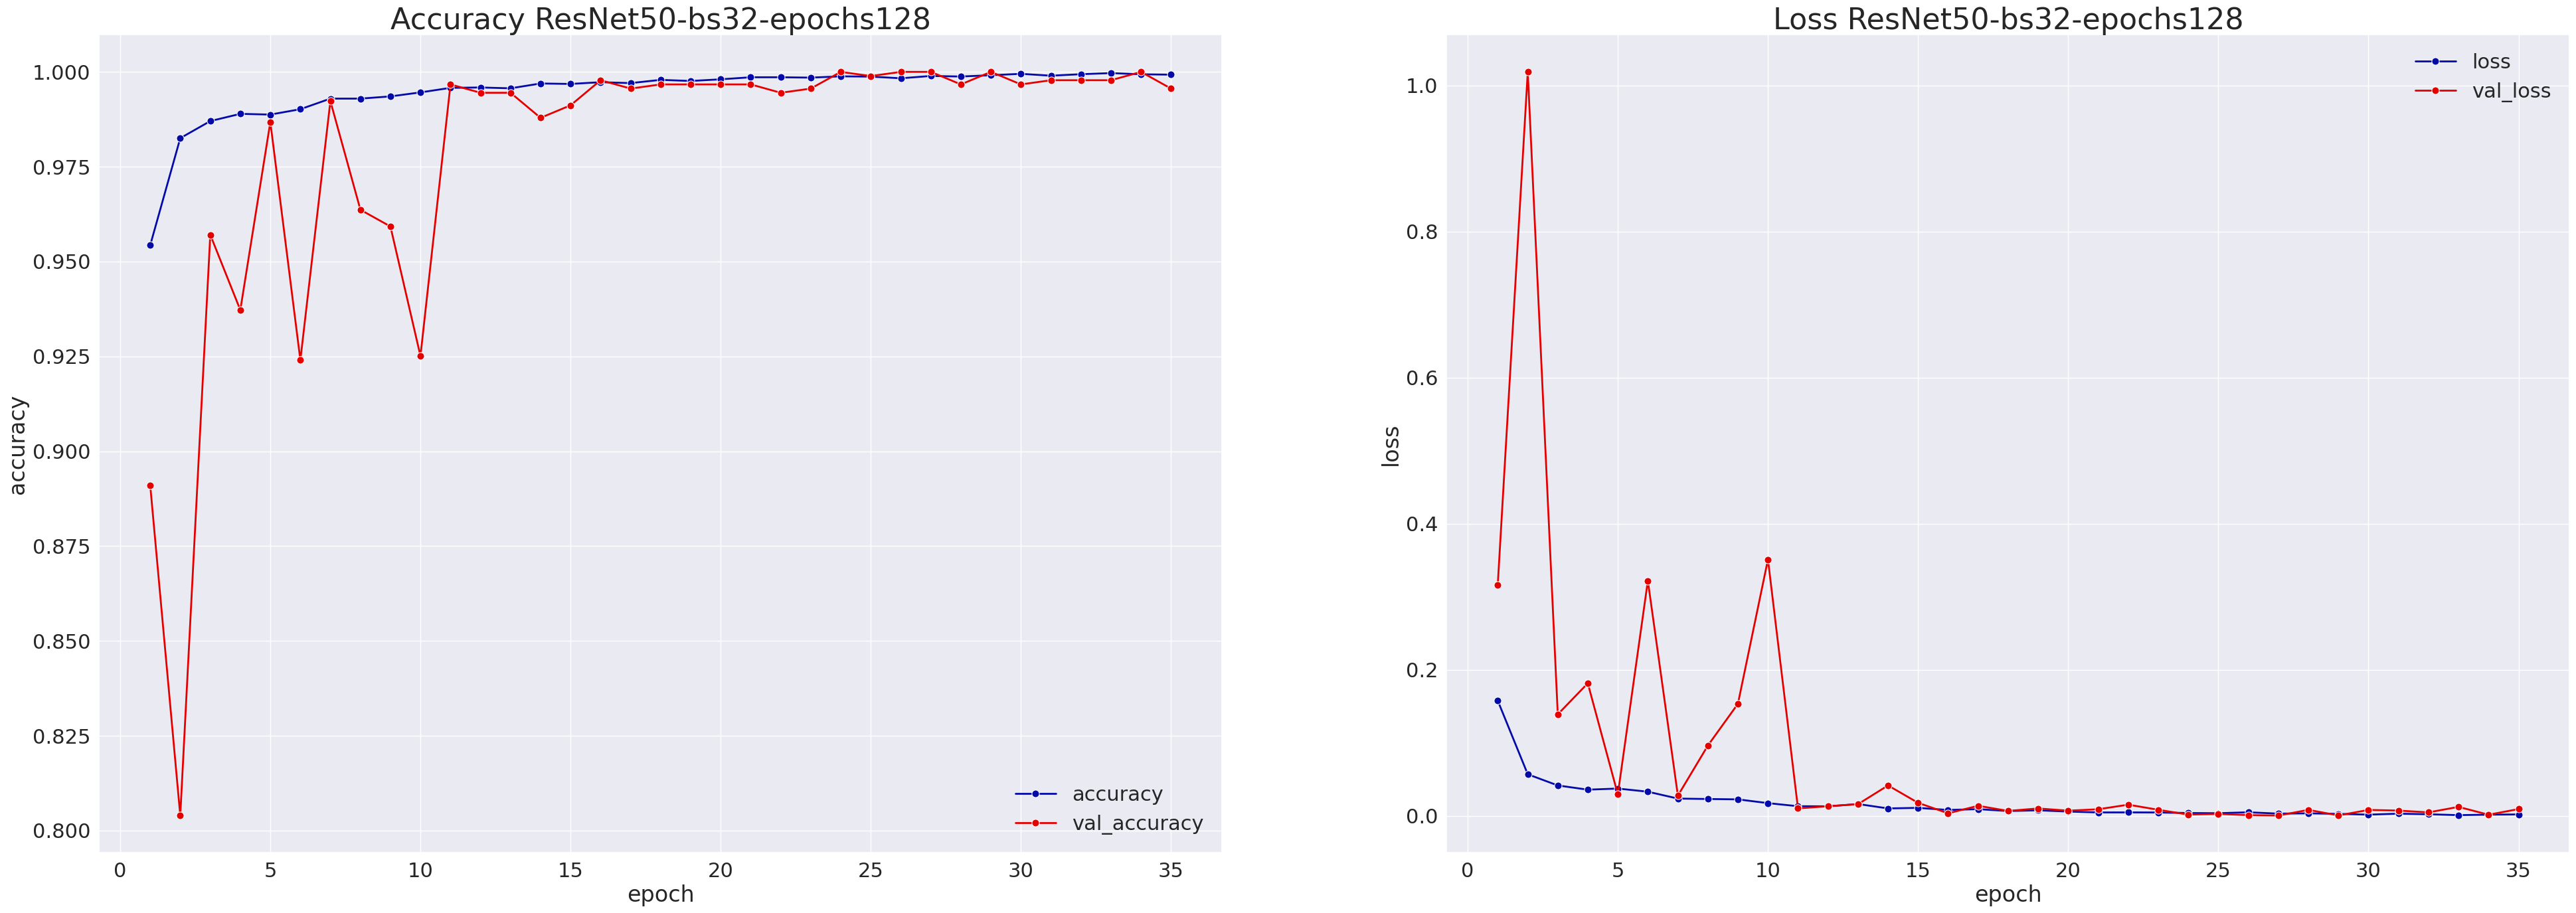

In [22]:
afficheHistoriqueEntrainement(historique, palette, f'{nomModel}-bs{batch_size:02d}-epochs{epochs:03d}', repertoireEnregistrement)

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Sauvegarde du modèle </div></b>

In [30]:
model.save(os.path.join(repertoireModelSauvegarde,f'{nomModel}-bs{batch_size:02d}-epochs{epochs:03d}.keras'))
model.save_weights(os.path.join(repertoireModelSauvegarde,f'{nomModel}-bs{batch_size:02d}-epochs{epochs:03d}.weights.h5'), overwrite=True)

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Inférence</div></b>

In [24]:
for i, (img,lab) in enumerate(pipelineValidation): 
    images, labels = img if i==0 else tf.concat([images,img], 0), lab if i==0 else tf.concat([labels,lab], 0)

In [25]:
probabilities = model.predict(images, verbose=0)
predictions = np.argmax(probabilities, axis=-1)

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:100%; border-radius:10px 10px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Probabilités pour les 8 premiers prédictions </div></b>

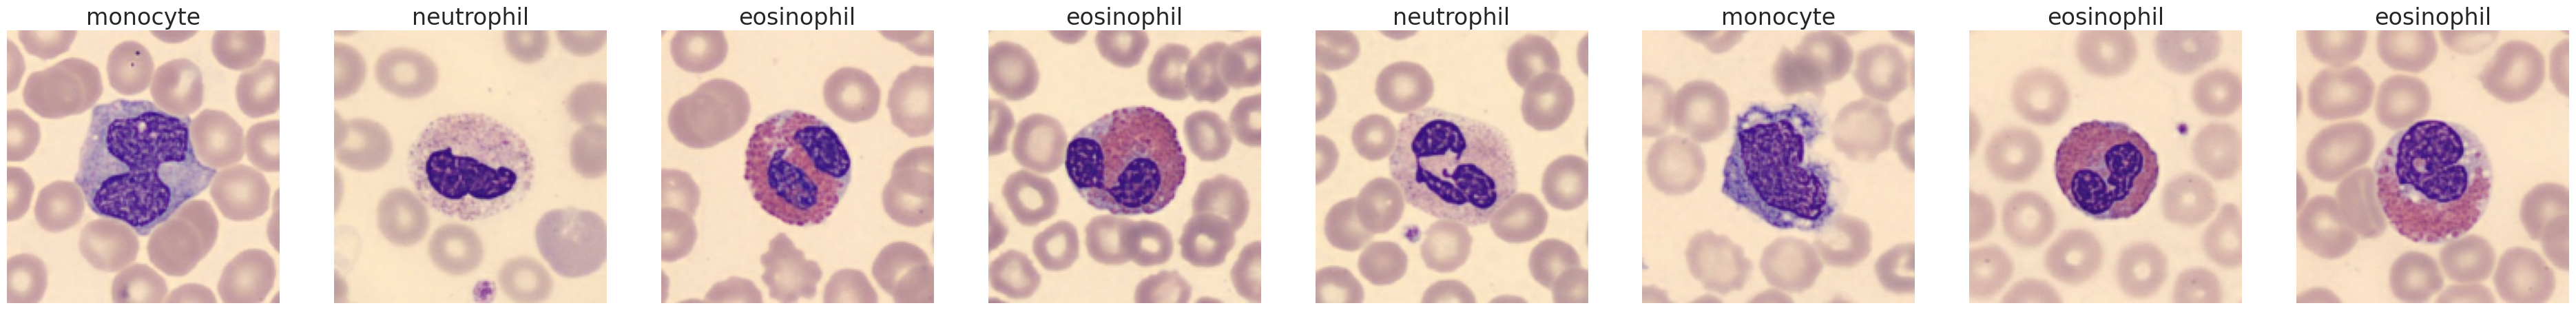

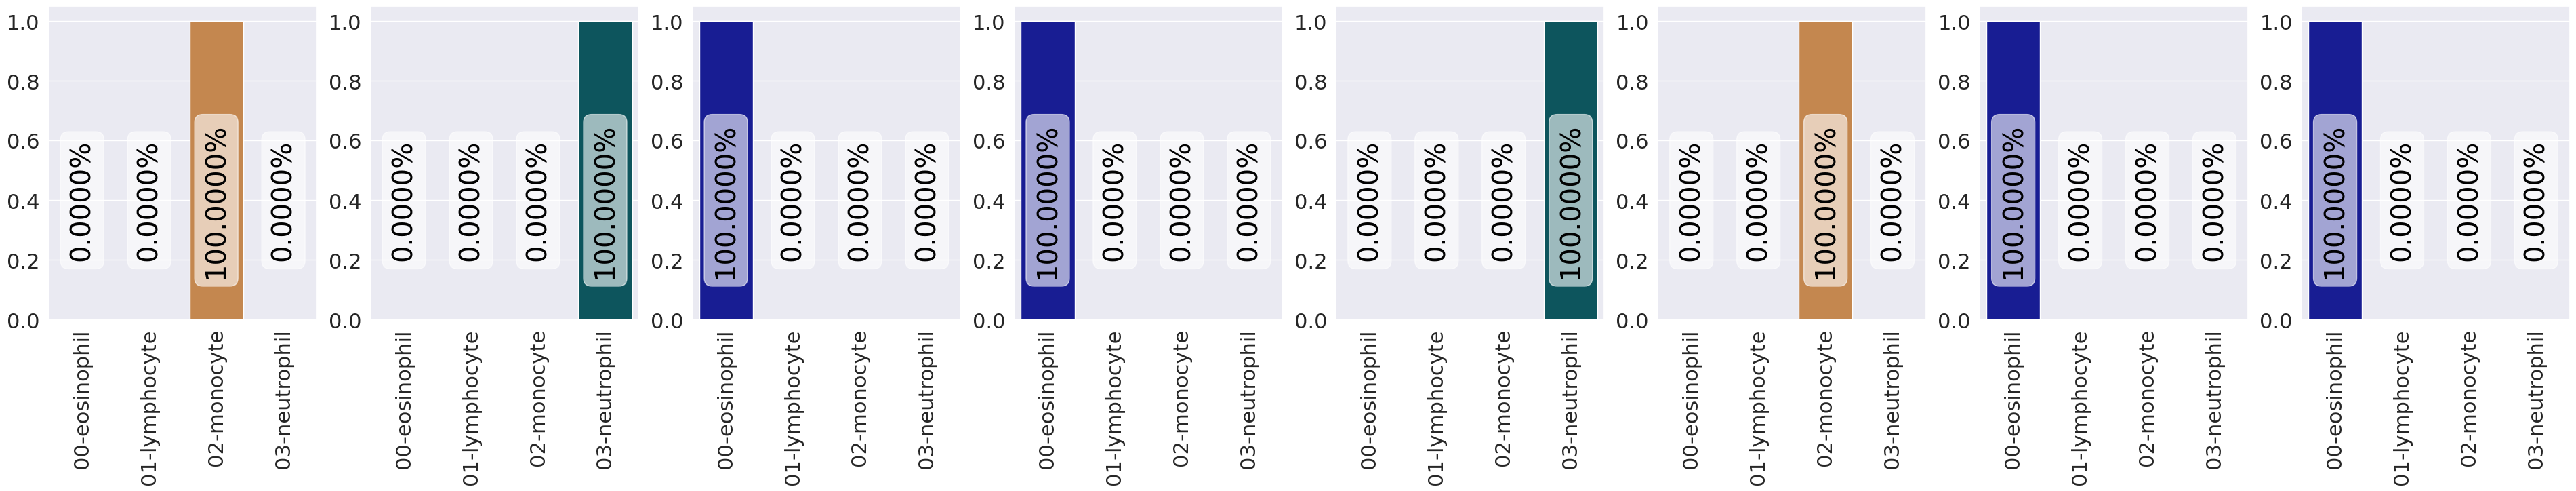

In [26]:
nombresImages = 8
afficheDataset(images, labels,nombresImages,6*nombresImages,dictLabels,cmap=None)
fig, ax = plt.subplots(nrows=1, ncols=nombresImages,figsize=(6*nombresImages,6));
for i in range(nombresImages):
    afficheProbabilites(probabilities,ind=i,ax=ax[i], dictLabels=dictLabels)

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:100%; border-radius:10px 10px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Matrice de Confusion </div></b>

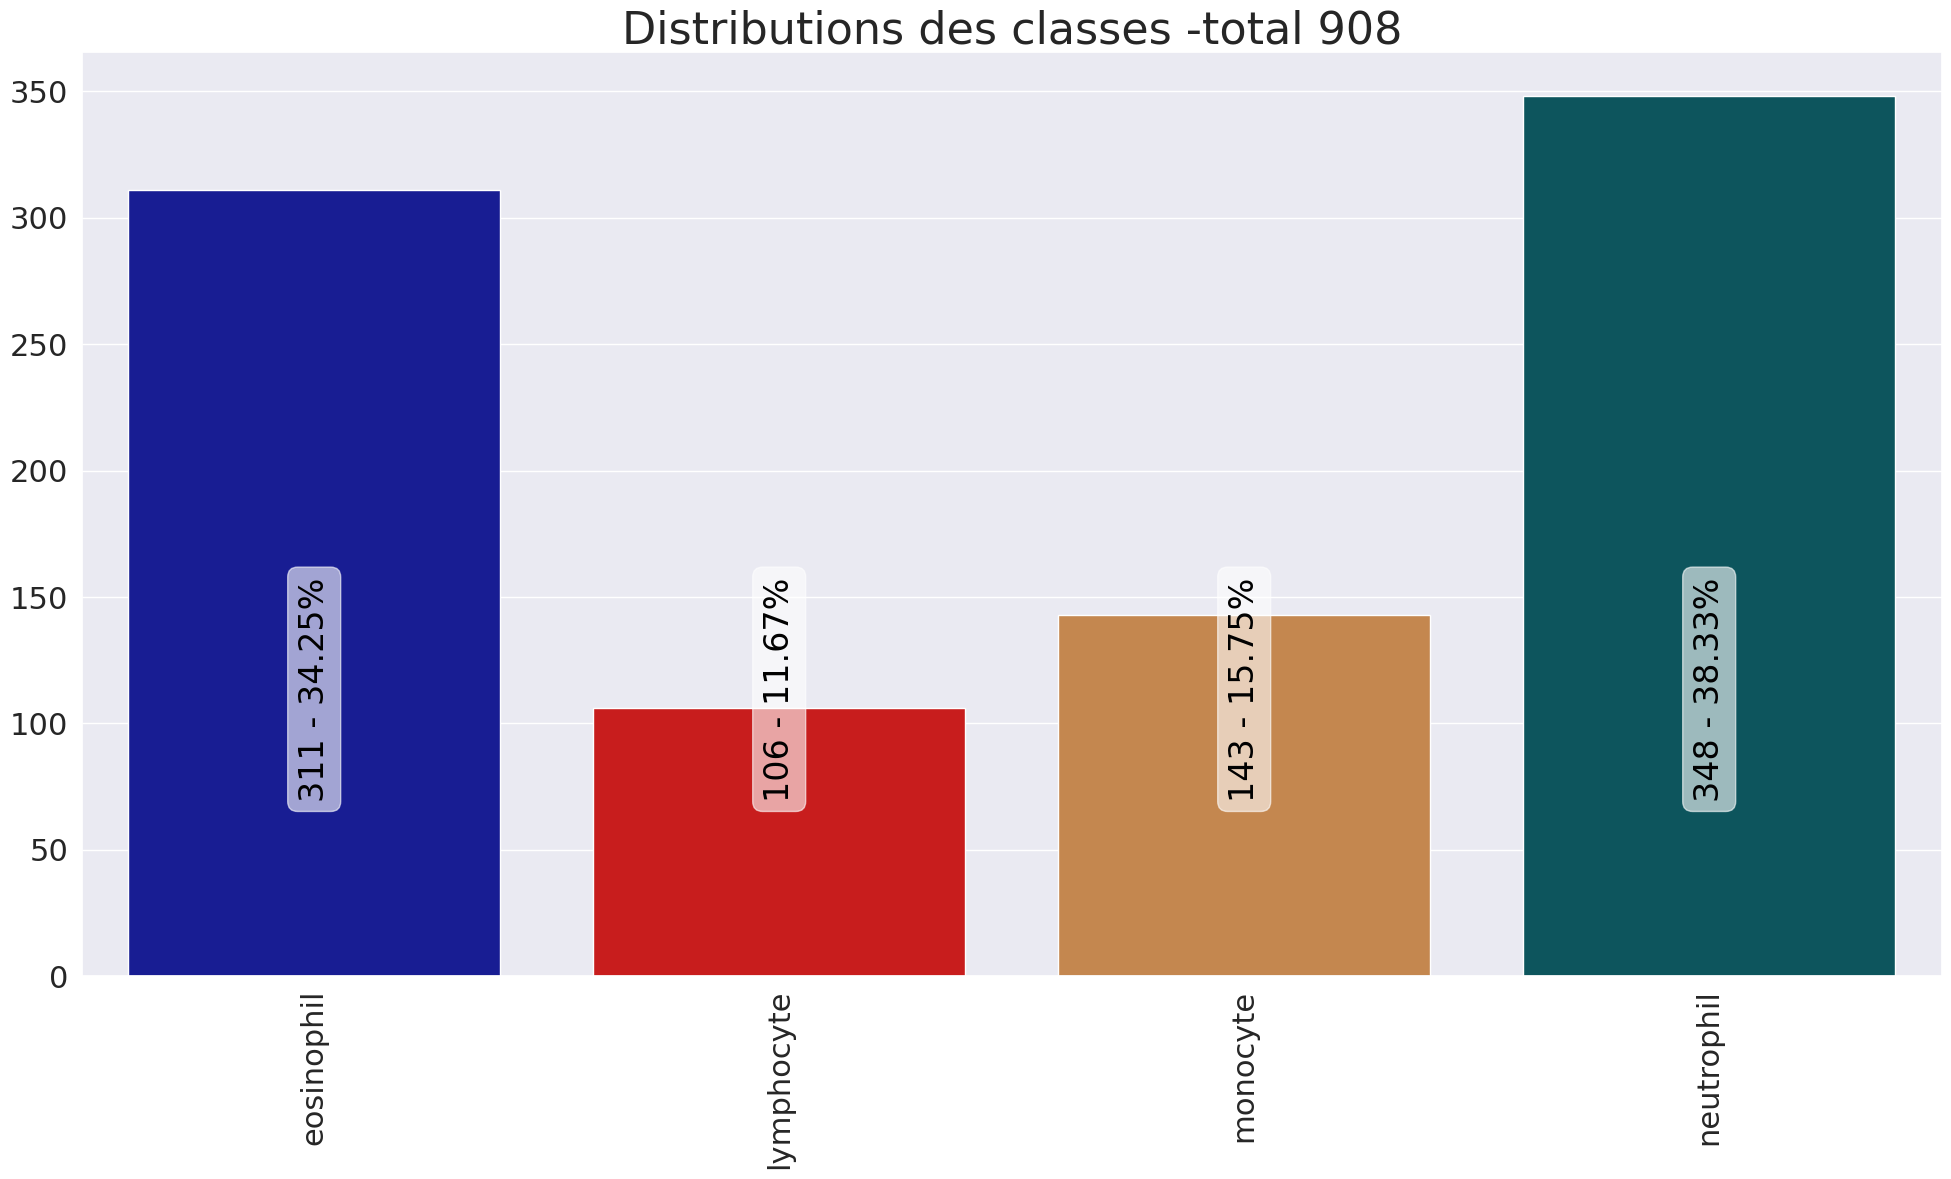

In [27]:
afficheDistributionsPipe(pipelineValidation, dictLabels, palette, repertoireEnregistrement=None)

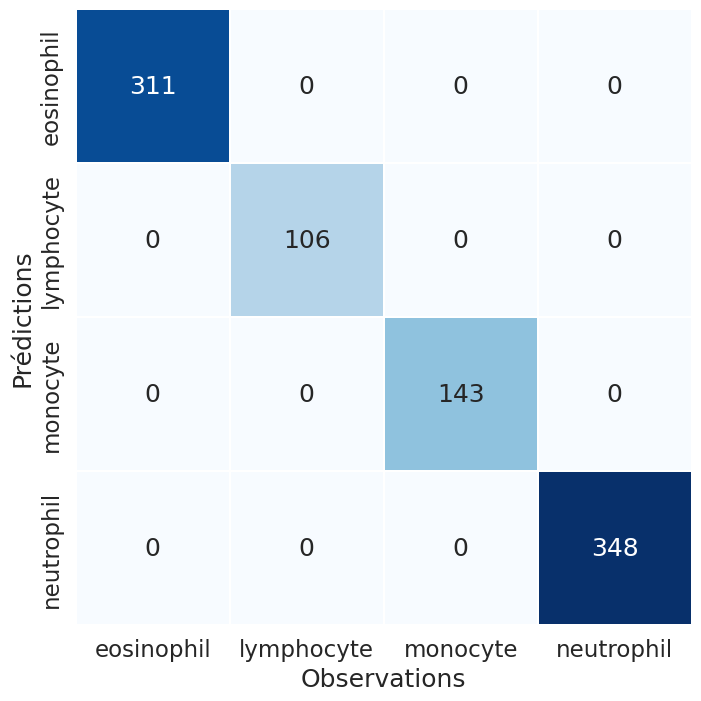

In [28]:
afficheMatriceConfusion(observations=labels,predictions=predictions,dictLabels=dictLabels, repertoireEnregistrement=repertoireEnregistrement,
                        nom_essai = f'{nomModel}-bs{batch_size:02d}-epochs{epochs:03d}')

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:100%; border-radius:10px 10px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Résultats de l’apprentissage</div></b>

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Area under the ROC curve : 1.0000	--	Exécution  :2.48s


,Classe,aucROC,avgPrecRec,f1,f2,f05,accuracy,precision,sensibilite,vrais_positifs,vrais_negatifs,faux_positifs,faux_negatifs,total_positifs,essai
0,global,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,908,2724,0,0,908,ResNet50-bs32-epochs128
1,eosinophil,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,311,597,0,0,311,ResNet50-bs32-epochs128
2,lymphocyte,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,106,802,0,0,106,ResNet50-bs32-epochs128
3,monocyte,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,143,765,0,0,143,ResNet50-bs32-epochs128
4,neutrophil,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,348,560,0,0,348,ResNet50-bs32-epochs128


<Figure size 1800x1800 with 0 Axes>

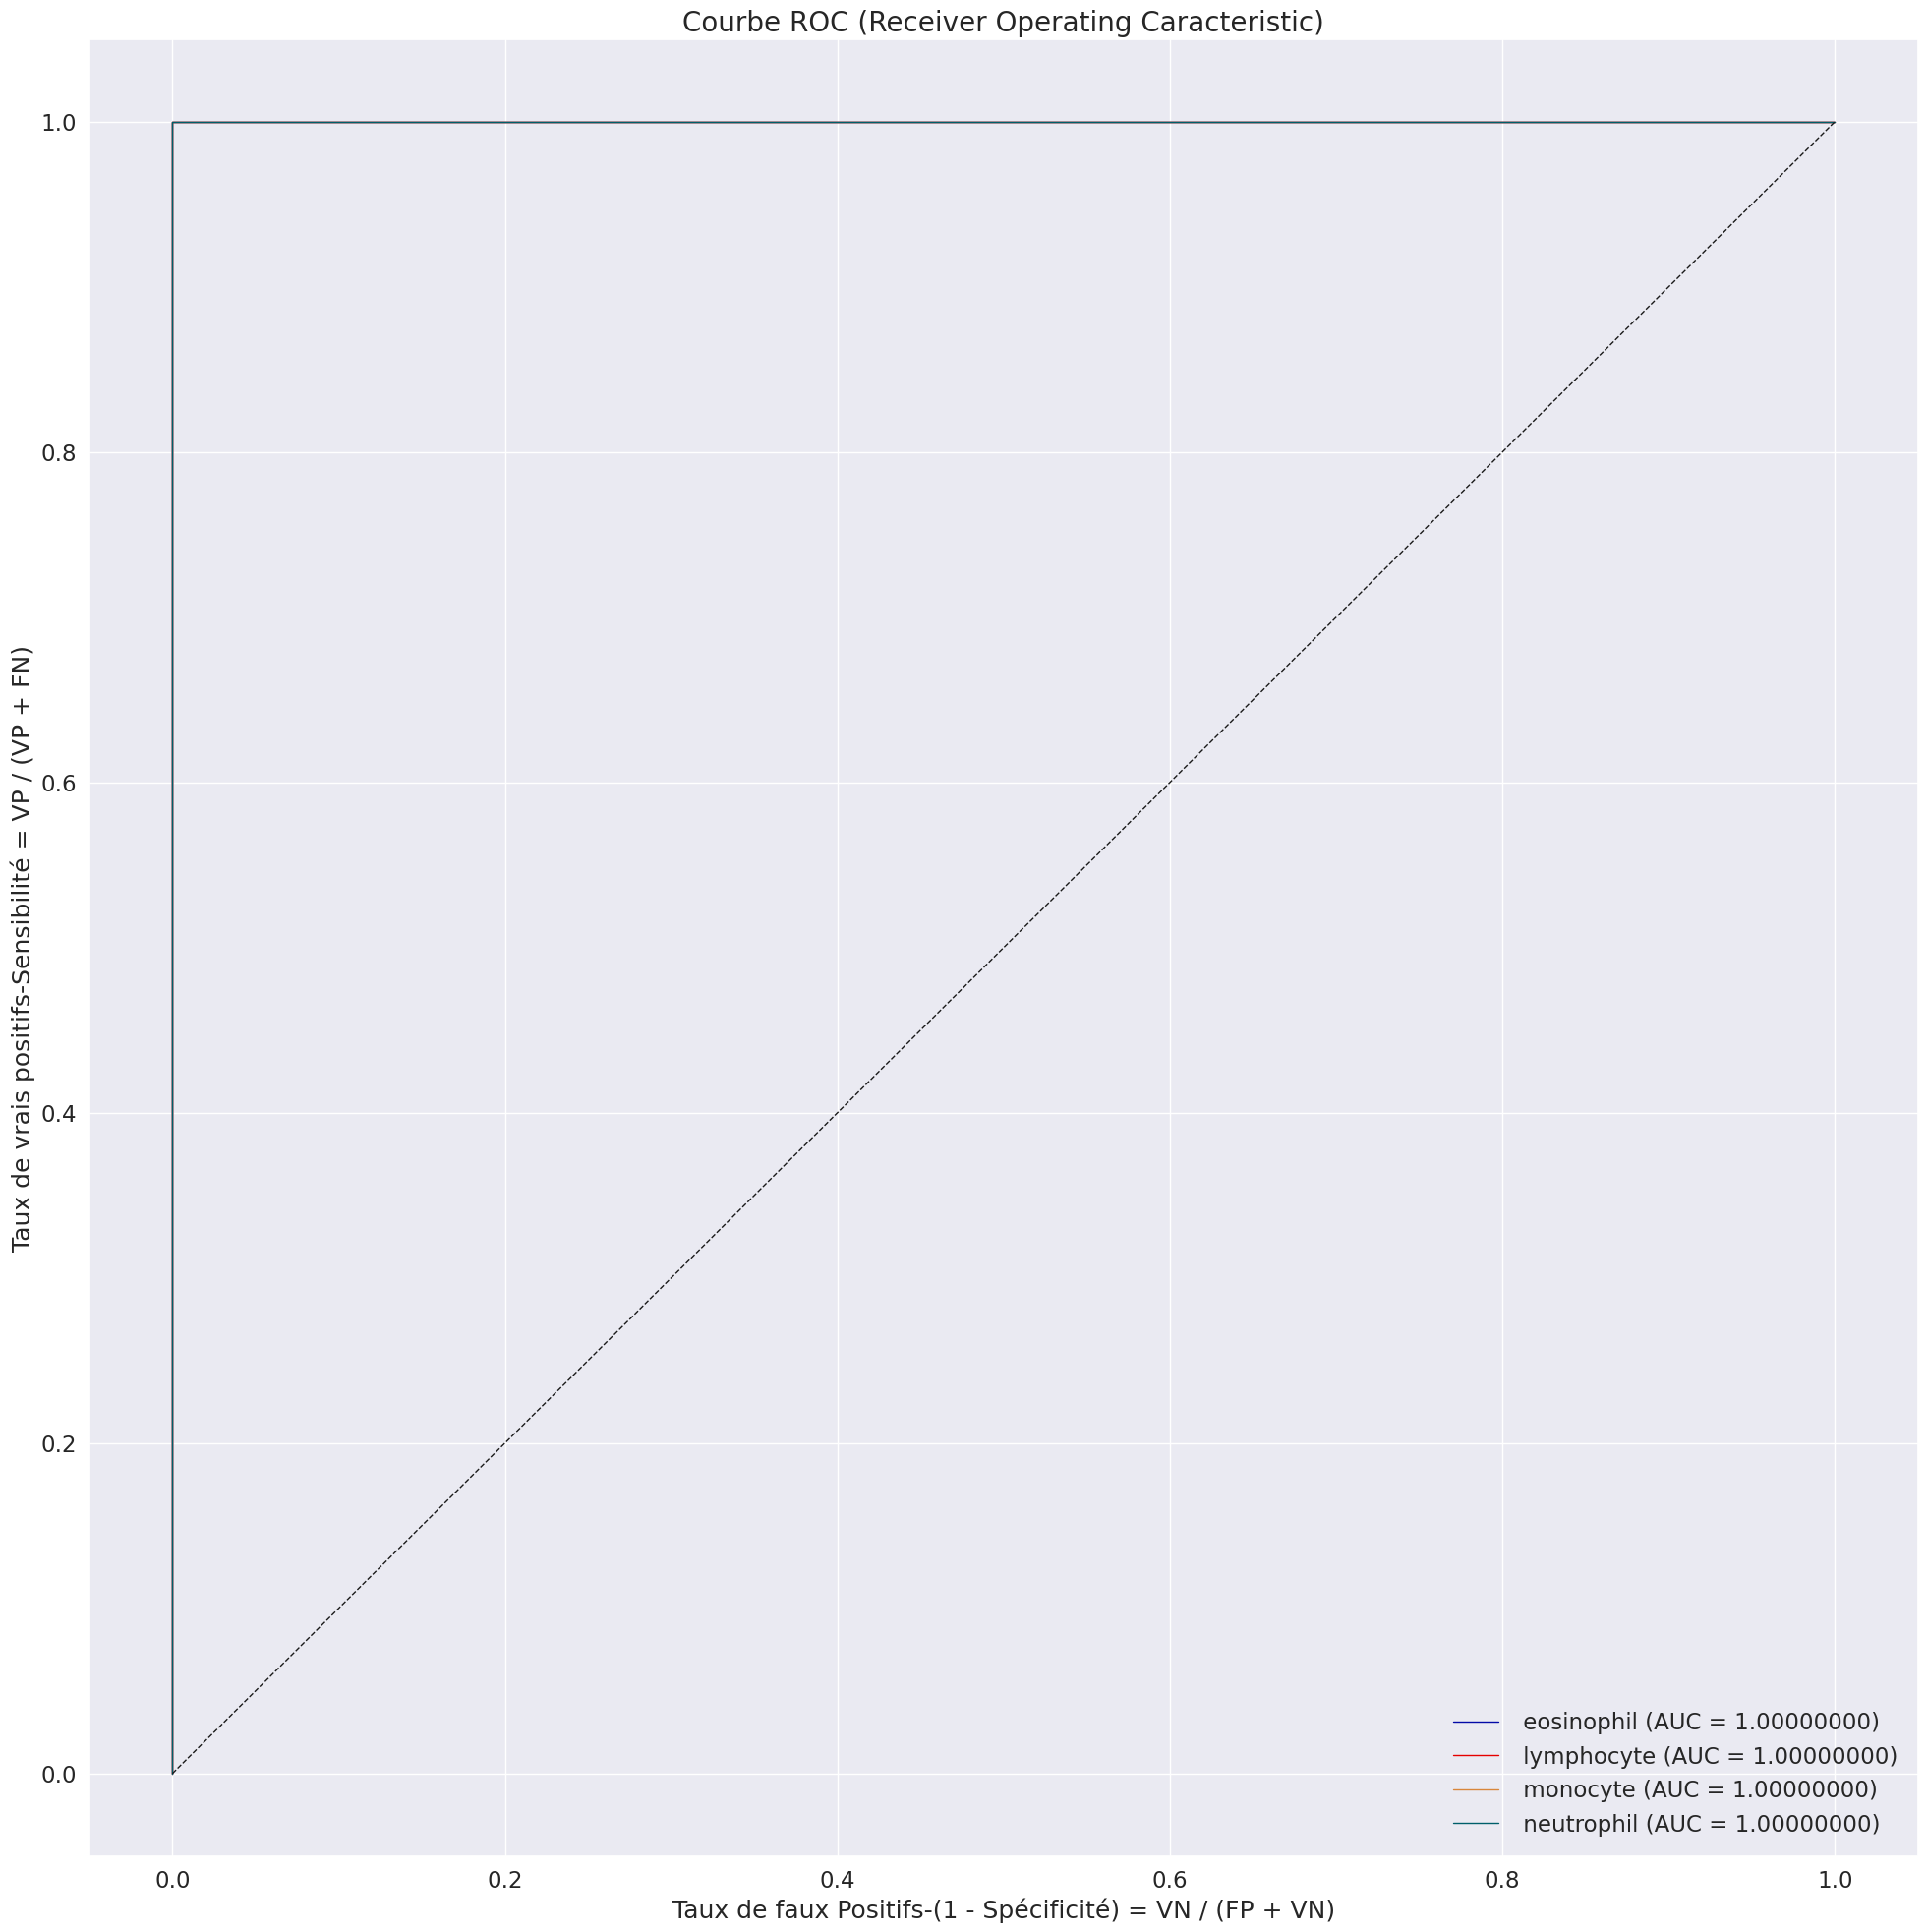

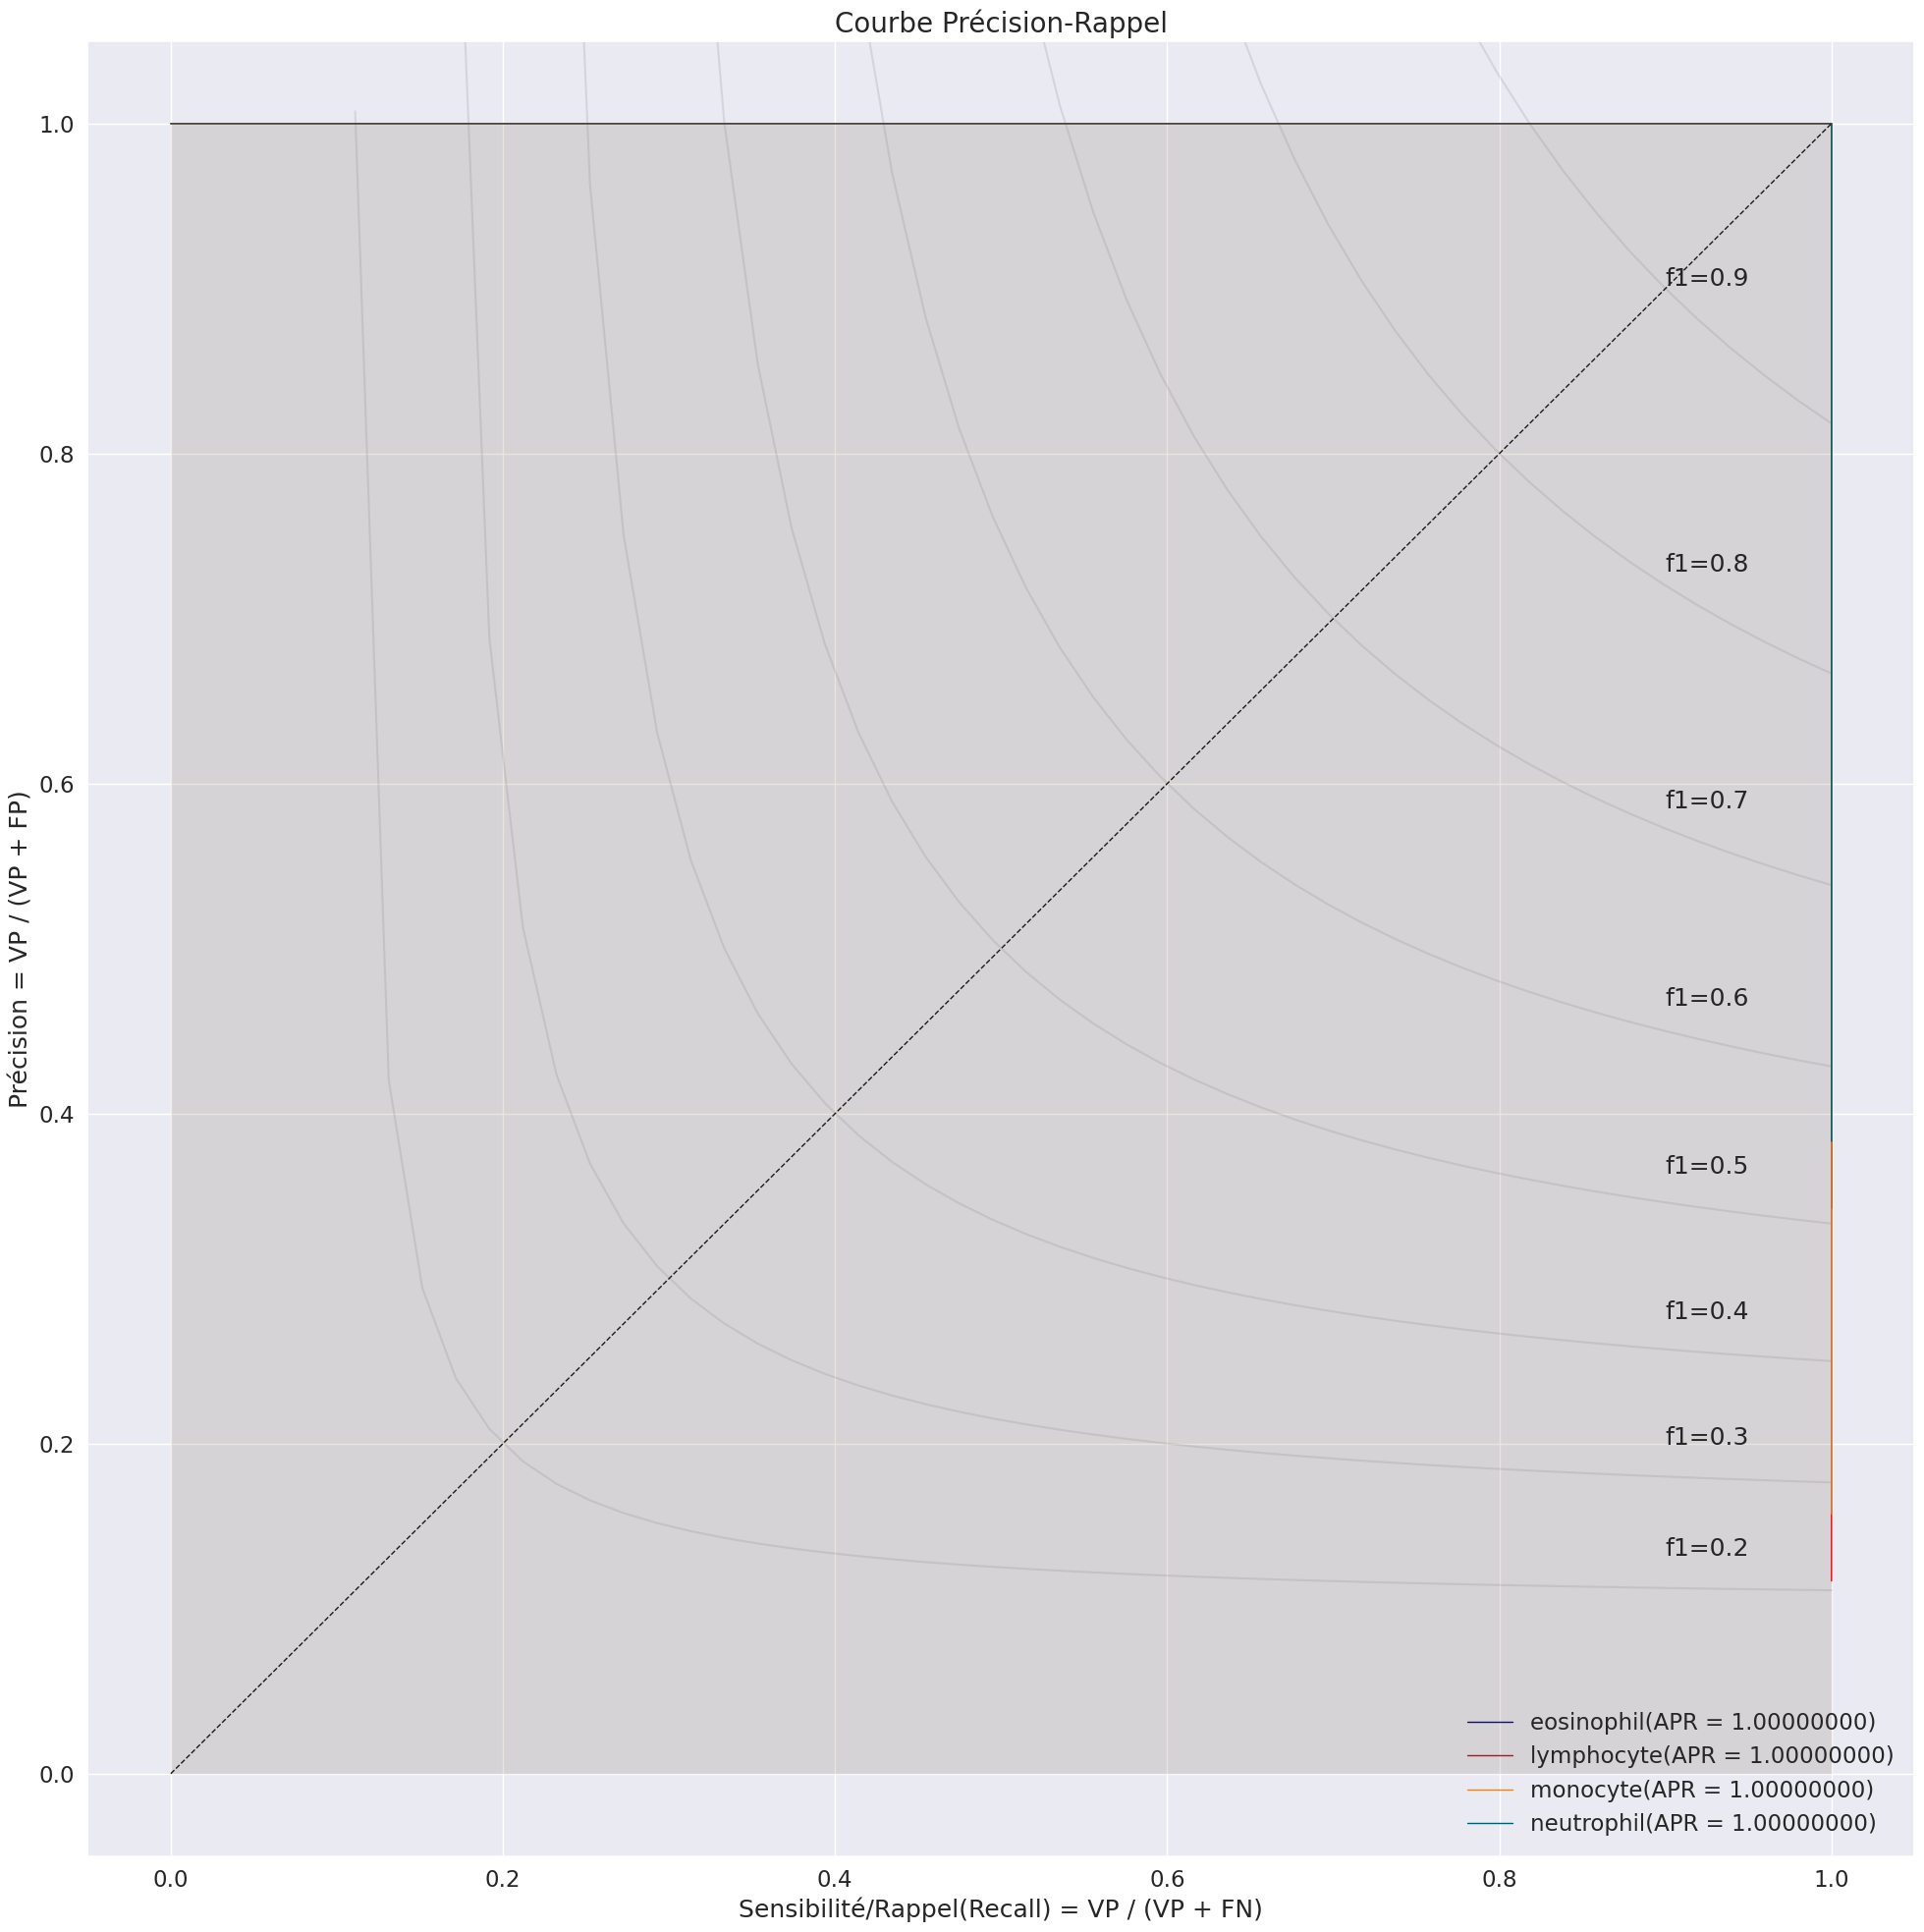

In [29]:
resultats = executeApprentissageChoixClassifieurs(
                                                  model,
                                                  X_test=images,
                                                  y_test=labels,
                                                  label_dict=dictLabels,
                                                  palette=palette, 
                                                  repertoireEnregistrement=repertoireEnregistrement,    
                                                  nom_essai = f'{nomModel}-bs{batch_size:02d}-epochs{epochs:03d}',
                                                 );

resultats.to_parquet(os.path.join(repertoireSauvegardes,f'resultats-{nomModel}-bs{batch_size:02d}-epochs{epochs:03d}.gzip'),compression='gzip', engine='pyarrow')

resultats